## Predicting Airbnb Listing Prices Using Deep Learning and Machine Learning Models


Lydia Reilly, Chloe , Gabe

In [ ]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic('matplotlib', 'inline')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

try:
    import tensorflow as tf
    from tensorflow.keras import Input, Model, layers, regularizers
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    tf_available = True
    print('TensorFlow available:', tf.__version__)
except Exception as exc:
    tf_available = False
    print('TensorFlow unavailable:', exc)


TensorFlow available: 2.21.0


Looking at the dataset, and viewing the first few rows to understand the structure and content 
Understanding the features and target variable, and identifying any potential issues such as missing values or outliers

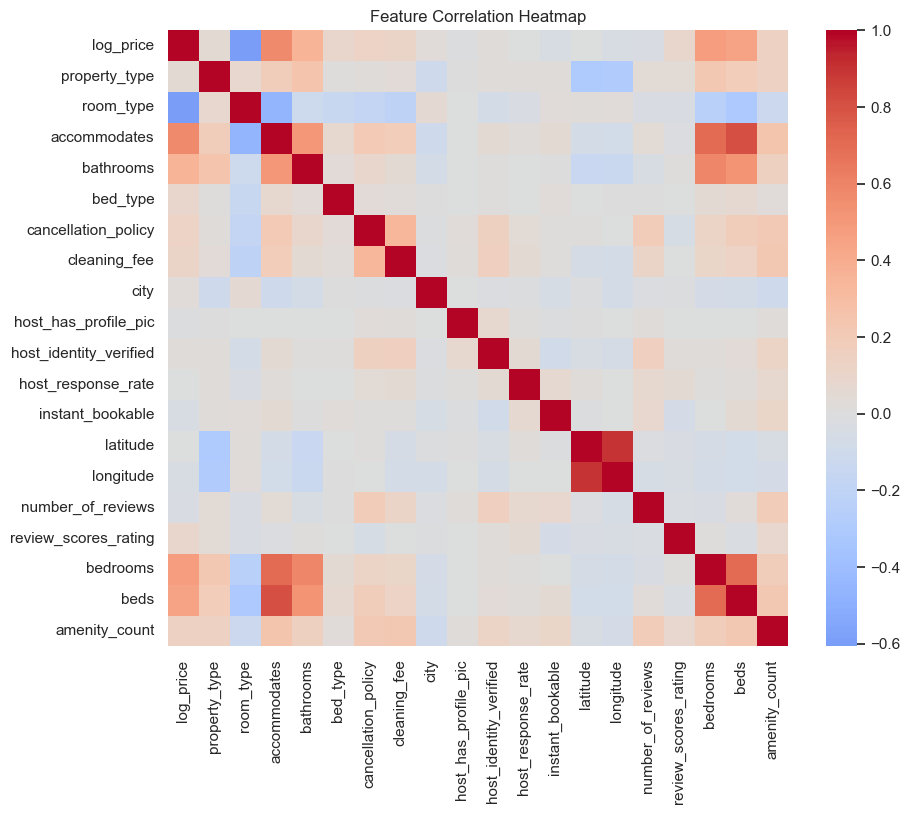

In [12]:
# show a graphic of the different features in the dataset, and how they relate to the target variable
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
data_path = 'Airbnb_Data.csv'
assert os.path.exists(data_path), f'Data file not found: {data_path}'

df = pd.read_csv(data_path)

# Basic feature cleanup
remove_cols = ['id', 'thumbnail_url', 'first_review', 'last_review', 'host_since', 'zipcode', 'neighbourhood', 'name']
df = df.drop(columns=remove_cols, errors='ignore').copy()

descriptions = df['description'].fillna('').astype(str).copy()
df = df.drop(columns=['description'], errors='ignore')

df['amenity_count'] = df['amenities'].apply(lambda x: len(re.findall(r'"[^"]+?"', str(x))))
df = df.drop(columns=['amenities'], errors='ignore')

df['host_response_rate'] = pd.to_numeric(df['host_response_rate'].astype(str).str.replace('%', '', regex=False), errors='coerce')

boolean_map = {'t': 1, 'f': 0, True: 1, False: 0}
for col in ['cleaning_fee', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map(boolean_map)

categorical_cols = [c for c in ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city'] if c in df.columns]
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

assert df.isnull().sum().sum() == 0, 'NaN values remain after imputation.'
print('Cleaned data shape:', df.shape)

# NLP semantic features from listing text
nlp_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2), min_df=5)),
    ('svd', TruncatedSVD(n_components=20, random_state=42))
])

nlp_features = nlp_pipeline.fit_transform(descriptions)
nlp_df = pd.DataFrame(nlp_features, columns=[f'nlp_{i}' for i in range(nlp_features.shape[1])], index=df.index)

full_df = pd.concat([df, nlp_df], axis=1)
feature_names = [c for c in full_df.columns if c != 'log_price']
print('Full feature matrix shape:', full_df.shape)

# Save the top NLP terms for interpretation
vocab = nlp_pipeline.named_steps['tfidf'].get_feature_names_out()
svd_comps = nlp_pipeline.named_steps['svd'].components_
for i in range(5):
    top_words = vocab[svd_comps[i].argsort()[-8:][::-1]]
    print(f'Component {i+1}:', ', '.join(top_words))

# Train/test split and scaling
X = full_df[feature_names].values
y = full_df['log_price'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train shape:', X_train_scaled.shape, 'Test shape:', X_test_scaled.shape)


Cleaned data shape: (74111, 20)
Full feature matrix shape: (74111, 40)
Component 1: room, apartment, bedroom, kitchen, place, private, bed, living
Component 2: place, place good, solo adventurers, adventurers, solo, place close, good, good couples
Component 3: apartment, train, subway, manhattan, park, brooklyn, walk, away
Component 4: room, living room, living, bed, bedroom, apartment, kitchen, size
Component 5: room, house, train, min, private, shared, minutes, minute
Train shape: (59288, 39) Test shape: (14823, 39)


In [8]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        'model': name,
        'fitted': model,
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
        'test_mae': mean_absolute_error(y_test, test_pred),
        'test_r2': r2_score(y_test, test_pred),
        'predictions': test_pred
    }

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge L2', Ridge(alpha=10.0)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)),
    ('MLP Regressor', MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
                                  alpha=0.001, learning_rate='adaptive', learning_rate_init=0.001,
                                  max_iter=300, early_stopping=True, validation_fraction=0.1,
                                  n_iter_no_change=15, random_state=42, verbose=False))
]

results = []
for name, model in models:
    print('Training', name)
    res = evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)
    results.append(res)
    if name == 'Ridge L2':
        print('  Ridge coefficients shape:', model.coef_.shape)
    if name == 'MLP Regressor':
        print('  MLP weights layers:', [coef.shape for coef in model.coefs_])

print('\nModel performance summary:')
for r in results:
    print(f"{r['model']:<15} RMSE={r['test_rmse']:.4f} MAE={r['test_mae']:.4f} R2={r['test_r2']:.4f}")


Training Linear Regression
Training Ridge L2
  Ridge coefficients shape: (39,)
Training Random Forest
Training MLP Regressor
  MLP weights layers: [(39, 128), (128, 64), (64, 32), (32, 1)]

Model performance summary:
Linear Regression RMSE=0.4497 MAE=0.3333 R2=0.6063
Ridge L2        RMSE=0.4497 MAE=0.3333 R2=0.6063
Random Forest   RMSE=0.3966 MAE=0.2875 R2=0.6938
MLP Regressor   RMSE=0.4281 MAE=0.3154 R2=0.6432


In [17]:
# 5-fold cross-validation for the regression models
cv_models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge L2', Ridge(alpha=10.0)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
]

print('\nCross-validation results:')
for name, model in cv_models:
    neg_mse = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    rmse_scores = np.sqrt(-neg_mse)
    print(f'{name:<15} CV RMSE mean={rmse_scores.mean():.4f} std={rmse_scores.std():.4f}')



Cross-validation results:
Linear Regression CV RMSE mean=0.4520 std=0.0055
Ridge L2        CV RMSE mean=0.4520 std=0.0055
Random Forest   CV RMSE mean=0.4042 std=0.0047


In [9]:
if tf_available:
    print('\nPreparing RNN dataset from text and structured features...')
    max_words = 10000
    max_length = 120
    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(descriptions)

    descriptions_seq = tokenizer.texts_to_sequences(descriptions)
    descriptions_pad = pad_sequences(descriptions_seq, maxlen=max_length, padding='post', truncating='post')

    idx = np.arange(len(full_df))
    train_idx, test_idx = train_test_split(idx, test_size=0.20, random_state=42)
    X_desc_train = descriptions_pad[train_idx]
    X_desc_test = descriptions_pad[test_idx]

    def build_rnn_model(structured_dim, text_maxlen, vocab_size):
        structured_input = Input(shape=(structured_dim,), name='structured_input')
        text_input = Input(shape=(text_maxlen,), name='text_input')

        x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(structured_input)
        x = layers.Dropout(0.2)(x)

        t = layers.Embedding(vocab_size, 32, input_length=text_maxlen)(text_input)
        t = layers.SpatialDropout1D(0.2)(t)
        t = layers.Bidirectional(layers.LSTM(32, kernel_regularizer=regularizers.l2(1e-4)))(t)

        combined = layers.concatenate([x, t])
        combined = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(combined)
        combined = layers.Dropout(0.25)(combined)
        output = layers.Dense(1, name='price_output')(combined)

        model = Model([structured_input, text_input], output)
        model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
        return model

    rnn_model = build_rnn_model(X_train_scaled.shape[1], max_length, max_words)
    rnn_model.summary()

    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = rnn_model.fit(
        [X_train_scaled, X_desc_train], y_train,
        validation_split=0.12,
        epochs=25,
        batch_size=64,
        callbacks=[early_stop],
        verbose=2
    )

    rnn_preds = rnn_model.predict([X_test_scaled, X_desc_test], verbose=0).flatten()
    rnn_result = {
        'model': 'RNN (LSTM)',
        'fitted': rnn_model,
        'train_rmse': None,
        'test_rmse': np.sqrt(mean_squared_error(y_test, rnn_preds)),
        'test_mae': mean_absolute_error(y_test, rnn_preds),
        'test_r2': r2_score(y_test, rnn_preds),
        'predictions': rnn_preds,
        'history': history.history
    }
    results.append(rnn_result)
    print('RNN model test RMSE:', rnn_result['test_rmse'], 'R2:', rnn_result['test_r2'])
else:
    print('\nTensorFlow unavailable; skipping RNN model.')



Preparing RNN dataset from text and structured features...


c:\Users\Lydia\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ structured_input    │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 120, 32)   │    320,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      5,120 │ structured_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 120, 32)   │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     16,640 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dropout_2[0][0],  │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     12,352 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         65 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 354,177 (1.35 MB)

 Trainable params: 354,177 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
816/816 - 41s - 51ms/step - loss: 0.9651 - rmse: 0.9708 - val_loss: 0.2230 - val_rmse: 0.4506
Epoch 2/25
816/816 - 33s - 40ms/step - loss: 0.4677 - rmse: 0.6705 - val_loss: 0.2103 - val_rmse: 0.4402
Epoch 3/25
816/816 - 35s - 43ms/step - loss: 0.4264 - rmse: 0.6411 - val_loss: 0.2158 - val_rmse: 0.4488
Epoch 4/25
816/816 - 35s - 43ms/step - loss: 0.3821 - rmse: 0.6072 - val_loss: 0.2019 - val_rmse: 0.4351
Epoch 5/25
816/816 - 36s - 44ms/step - loss: 0.3481 - rmse: 0.5798 - val_loss: 0.2102 - val_rmse: 0.4460
Epoch 6/25
816/816 - 38s - 46ms/step - loss: 0.3158 - rmse: 0.5522 - val_loss: 0.2108 - val_rmse: 0.4478
Epoch 7/25
816/816 - 38s - 47ms/step - loss: 0.2892 - rmse: 0.5285 - val_loss: 0.1964 - val_rmse: 0.4323
Epoch 8/25
816/816 - 39s - 48ms/step - loss: 0.2644 - rmse: 0.5052 - val_loss: 0.1999 - val_rmse: 0.4372
Epoch 9/25
816/816 - 37s - 46ms/step - loss: 0.2405 - rmse: 0.4817 - val_loss: 0.1940 - val_rmse: 0.4311
Epoch 10/25
816/816 - 36s - 45ms/step - loss: 0.2226 - 


Displaying evaluation plots...


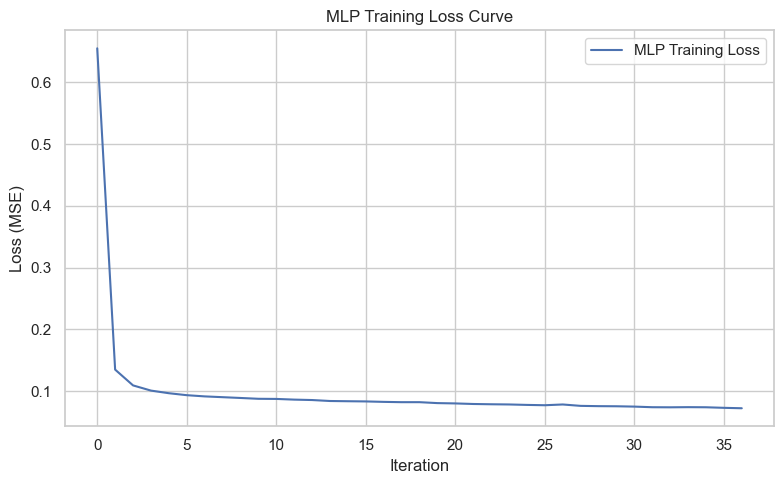

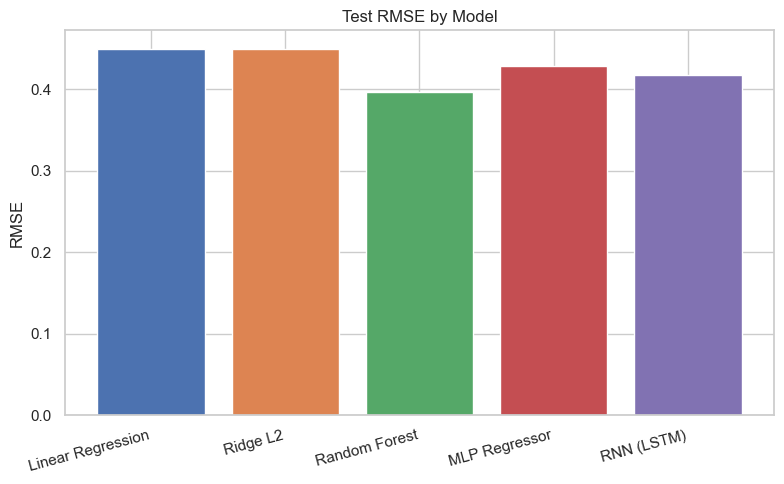

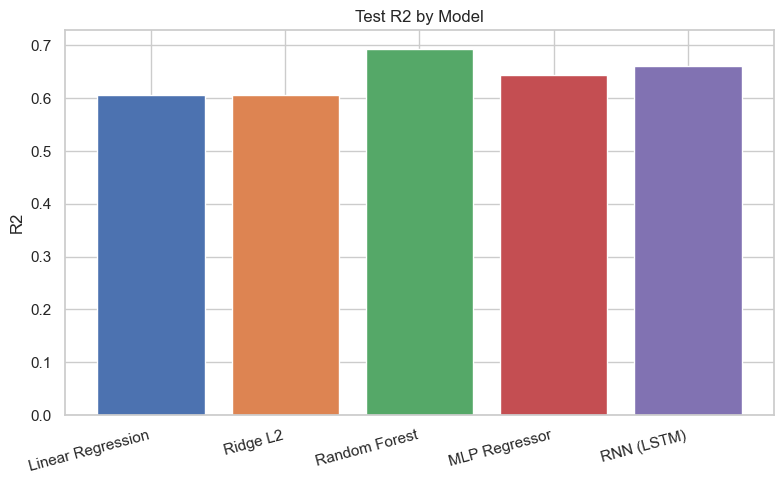

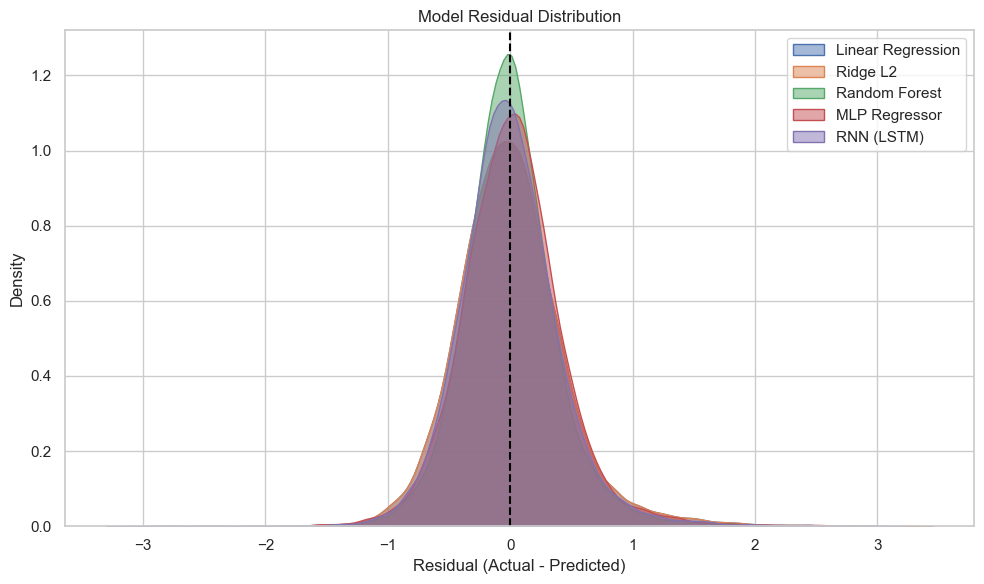

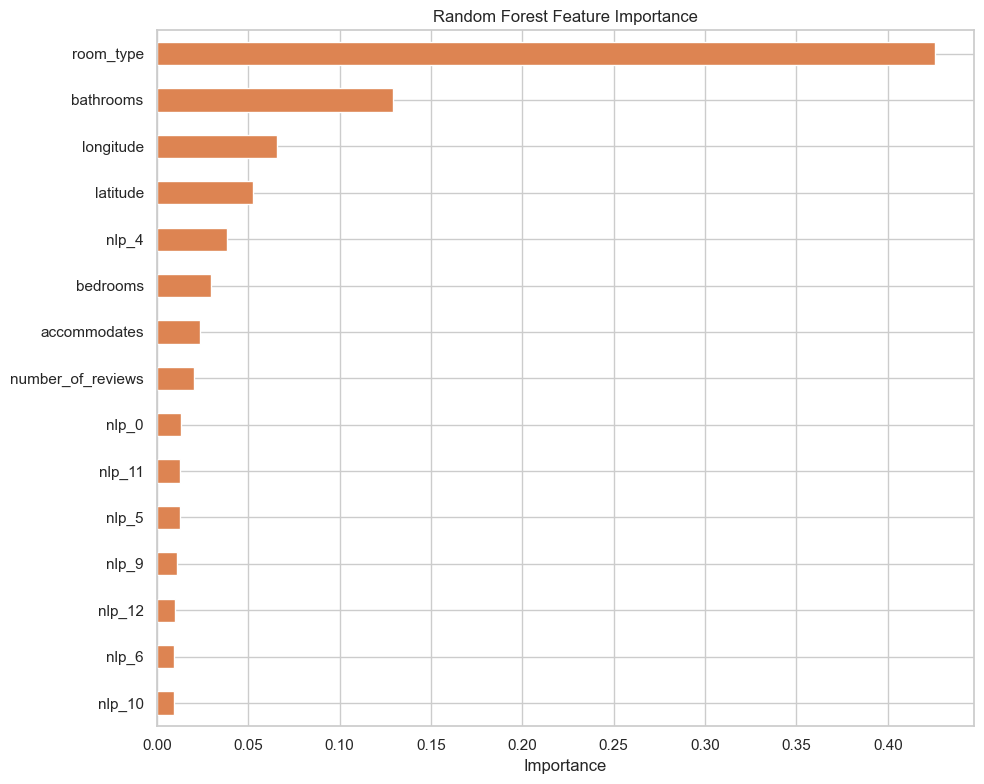

Displayed evaluation graphs.


In [10]:
print('\nDisplaying evaluation plots...')

if any(r['model'] == 'MLP Regressor' for r in results):
    mlp_res = next(r for r in results if r['model'] == 'MLP Regressor')
    plt.figure(figsize=(8, 5))
    plt.plot(mlp_res['fitted'].loss_curve_, color=COLORS[0], label='MLP Training Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (MSE)')
    plt.title('MLP Training Loss Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

labels = [r['model'] for r in results]
rmse_values = [r['test_rmse'] for r in results]
r2_values = [r['test_r2'] for r in results]

plt.figure(figsize=(8, 5))
plt.bar(labels, rmse_values, color=COLORS[:len(labels)])
plt.title('Test RMSE by Model')
plt.xticks(rotation=15, ha='right')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(labels, r2_values, color=COLORS[:len(labels)])
plt.title('Test R2 by Model')
plt.xticks(rotation=15, ha='right')
plt.ylabel('R2')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for idx, res in enumerate(results):
    residuals = y_test - res['predictions']
    sns.kdeplot(residuals, fill=True, label=res['model'], color=COLORS[idx % len(COLORS)], alpha=0.5)
plt.axvline(0, color='black', linestyle='--')
plt.title('Model Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.legend()
plt.tight_layout()
plt.show()

rf_model = next(r['fitted'] for r in results if r['model'] == 'Random Forest')
rf_feature_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
rf_feature_importance.head(15).sort_values().plot(kind='barh', color=COLORS[1])
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Displayed evaluation graphs.')
